In [38]:
import pandas as pd

## Load and clean

1. Read the raw TSV file
2. Split the first column (comma-separated) into: stat, unit, isced, sex, age, country
3. Reshape from wide (one column per year) to long (one row per year)
4. Clean values: remove flags like `b`, turn `:` into NaN, convert to numeric
5. Save as CSV

In [39]:
raw = pd.read_csv("estat_ilc_di08.tsv", sep="\t")

# split the first comma-separated column into separate metadata columns
meta_col = raw.columns[0]
meta = raw[meta_col].str.split(",", expand=True)
meta.columns = ["freq", "stat", "unit", "isced", "sex", "age", "country"]
meta = meta.drop(columns=["freq"])

# strip whitespace from year column names
year_cols = [c for c in raw.columns if c != meta_col]
years = raw[year_cols].copy()
years.columns = [c.strip() for c in years.columns]

# melt wide year columns into tidy long format
df = pd.concat([meta, years], axis=1).melt(
    id_vars=["country", "isced", "sex", "age", "stat", "unit"],
    var_name="year",
    value_name="value",
)

# strip flags (b), convert ':' to NaN, make numeric
df["value"] = (
    df["value"]
    .str.strip()
    .str.replace(r"\s*[a-z]", "", regex=True)
    .replace(":", pd.NA)
)
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["year"] = df["year"].astype(int)
df = df.sort_values(["country", "year"]).reset_index(drop=True)

## Verify and save

In [40]:
print(f"{len(df)} rows, {df['country'].nunique()} geos, {df['year'].min()}-{df['year'].max()}")
print(f"Missing: {df['value'].isna().sum()} / {len(df)}")
df.to_csv("clean_data.csv", index=False)

160218 rows, 46 geos, 2003-2025
Missing: 36300 / 160218


## Load test

In [41]:
test = pd.read_csv("clean_data.csv")
test.dtypes

country     object
isced       object
sex         object
age         object
stat        object
unit        object
year         int64
value      float64
dtype: object

## (1) Income time series by education level

In [42]:
import matplotlib.pyplot as plt

# filter to baseline slice: mean income, EUR, total sex, working age
base = df[(df["stat"] == "MEAN_EI") & (df["unit"] == "EUR") &
          (df["sex"] == "T") & (df["age"] == "Y18-64")].copy()

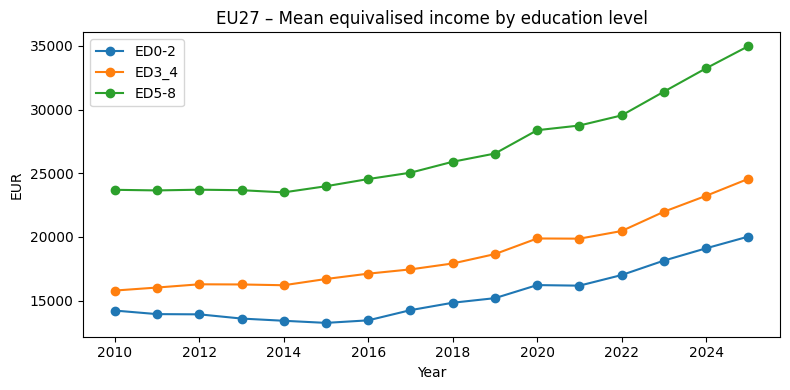

In [43]:
# EU aggregate time series
eu = base[base["country"] == "EU27_2020"]
fig, ax = plt.subplots(figsize=(8, 4))
for isced, grp in eu.groupby("isced"):
    ax.plot(grp["year"], grp["value"], marker="o", label=isced)
ax.set_title("EU27 – Mean equivalised income by education level")
ax.set_xlabel("Year")
ax.set_ylabel("EUR")
ax.legend()
plt.tight_layout()
plt.show()

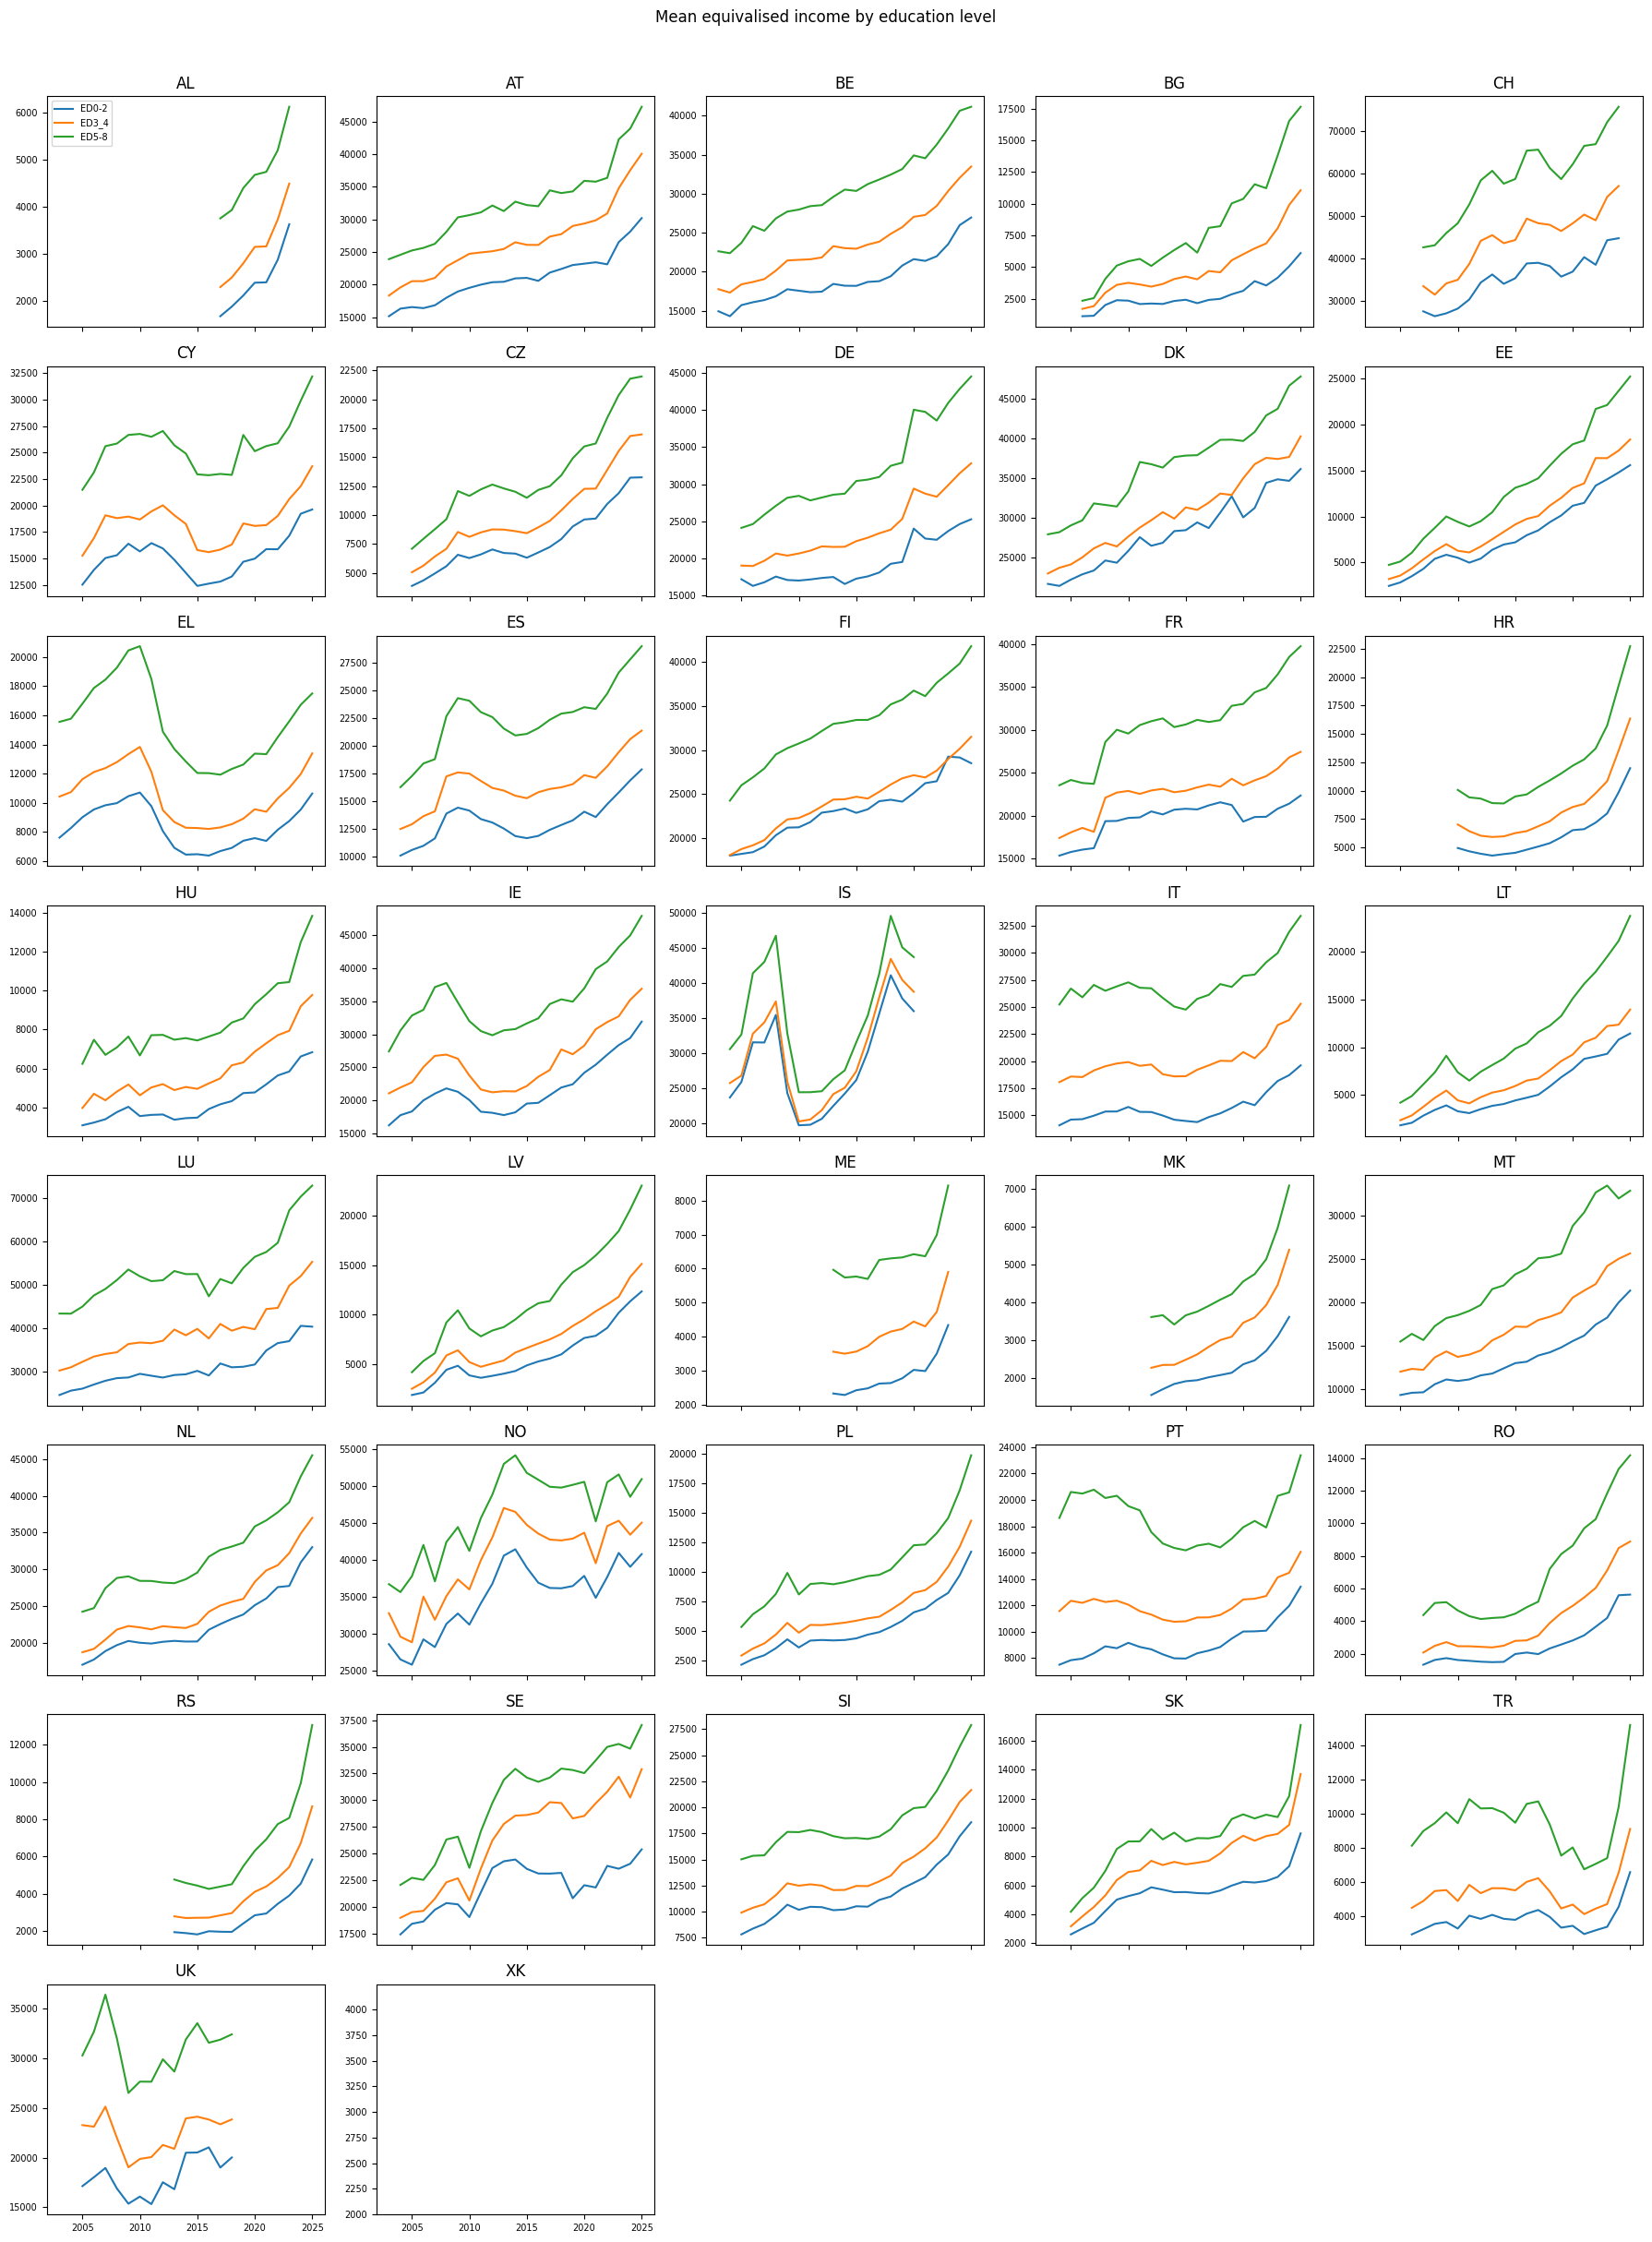

In [44]:
# per-country time series (small multiples)
countries = sorted(c for c in base["country"].unique()
                   if c not in ["EU", "EU27_2007", "EU27_2020", "EU28",
                                "EA", "EA18", "EA19", "EA20", "EA21"])
ncols = 5
nrows = -(-len(countries) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows), sharex=True)
axes = axes.flatten()

for i, ctry in enumerate(countries):
    ax = axes[i]
    sub = base[base["country"] == ctry]
    for isced, grp in sub.groupby("isced"):
        ax.plot(grp["year"], grp["value"], label=isced)
    ax.set_title(ctry)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=7)
fig.suptitle("Mean equivalised income by education level", y=1.01)
plt.tight_layout()
plt.show()

## (2) Cross-country bar chart – most recent complete year

In [45]:
# find the most recent year where all 3 ISCED groups have data for each country
bar = base[base["country"].isin(countries)].copy()
complete = (bar.groupby(["country", "year"])["value"]
            .apply(lambda x: x.notna().sum() == 3))
complete = complete[complete].reset_index().drop(columns="value")
latest_year = complete["year"].max()
print(f"Most recent complete year: {latest_year}")

snap = bar[(bar["year"] == latest_year) & bar["value"].notna()]
snap = snap.sort_values("country")

Most recent complete year: 2025


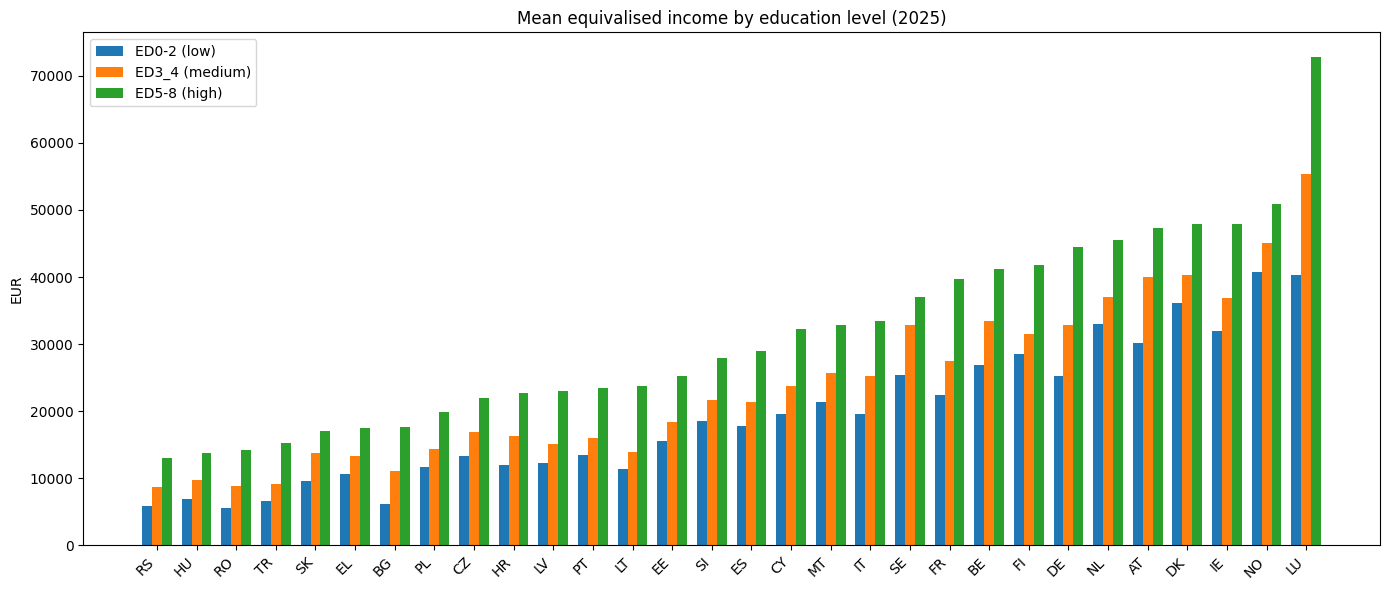

In [46]:
import numpy as np

pivot = snap.pivot_table(index="country", columns="isced", values="value")
pivot = pivot[["ED0-2", "ED3_4", "ED5-8"]].dropna().sort_values("ED5-8")

x = np.arange(len(pivot))
w = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w, pivot["ED0-2"], w, label="ED0-2 (low)")
ax.bar(x, pivot["ED3_4"], w, label="ED3_4 (medium)")
ax.bar(x + w, pivot["ED5-8"], w, label="ED5-8 (high)")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("EUR")
ax.set_title(f"Mean equivalised income by education level ({latest_year})")
ax.legend()
plt.tight_layout()
plt.show()